In [21]:
from PATHS import DATA_FOLDER
from data_prep import merge_open_close, prepare_data

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import seaborn as sns

import shap

C:\Users\User\anaconda3\envs\Basic\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
open_df = pd.read_csv(DATA_FOLDER + 'M15/open_trades.csv',sep=';')
close_df = pd.read_csv(DATA_FOLDER + 'M15/closed_trades.csv',sep=';')

merge_df = merge_open_close(open_df,close_df)

In [4]:
train_df = prepare_data(merge_df)
short_train_df = train_df[train_df['Type_open'] == 'Short']
long_train_df = train_df[train_df['Type_open'] == 'Long']


=== Decision Tree ===
Accuracy: 0.6973271614155592
              precision    recall  f1-score   support

           0       0.69      0.99      0.82      4578
           1       0.82      0.06      0.10      2119

    accuracy                           0.70      6697
   macro avg       0.76      0.52      0.46      6697
weighted avg       0.74      0.70      0.59      6697


=== Random Forest ===
Accuracy: 0.7852769896968792
              precision    recall  f1-score   support

           0       0.77      0.99      0.86      4578
           1       0.93      0.35      0.51      2119

    accuracy                           0.79      6697
   macro avg       0.85      0.67      0.68      6697
weighted avg       0.82      0.79      0.75      6697


=== XGBoost ===
Accuracy: 0.8887561594743916
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      4578
           1       0.89      0.74      0.81      2119

    accuracy                    

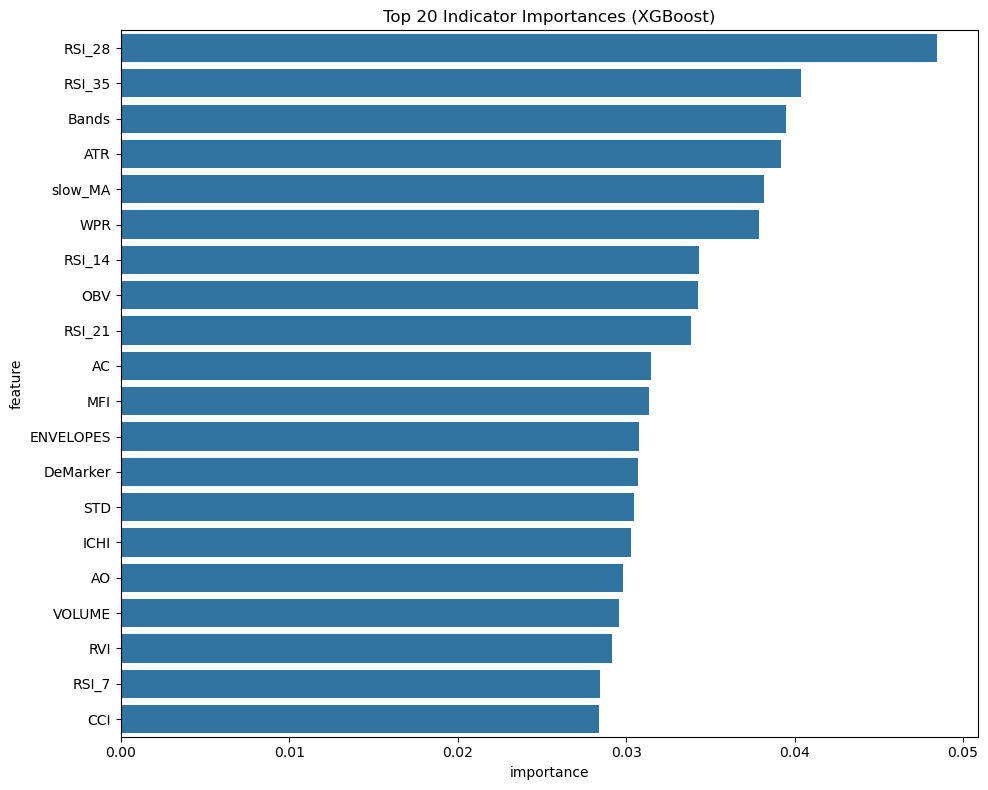

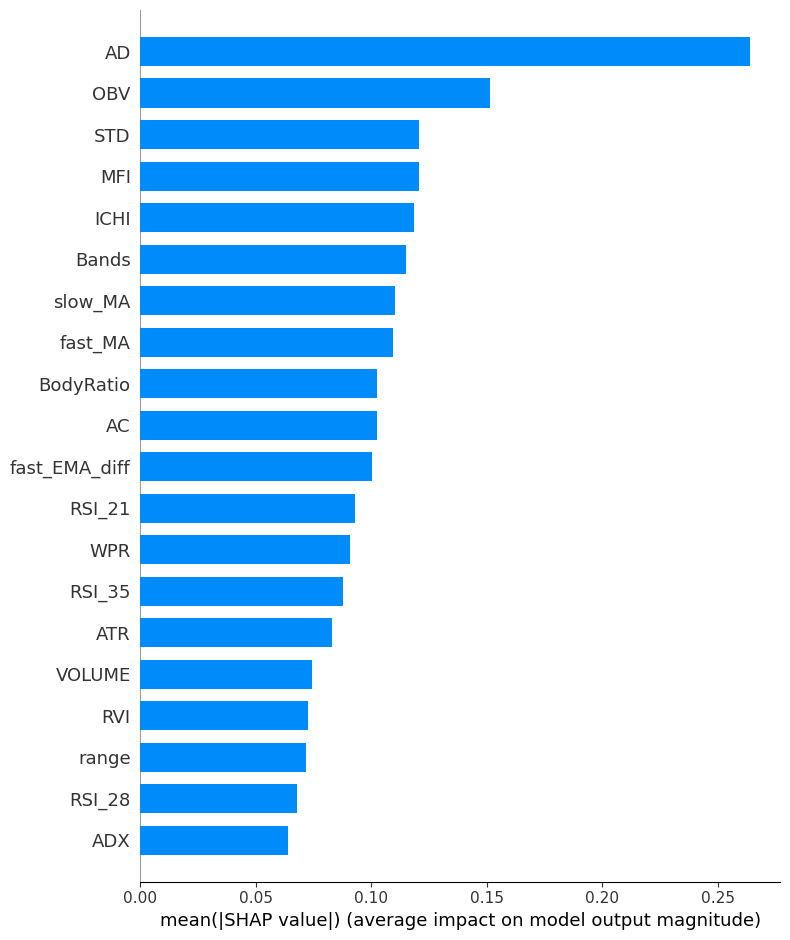

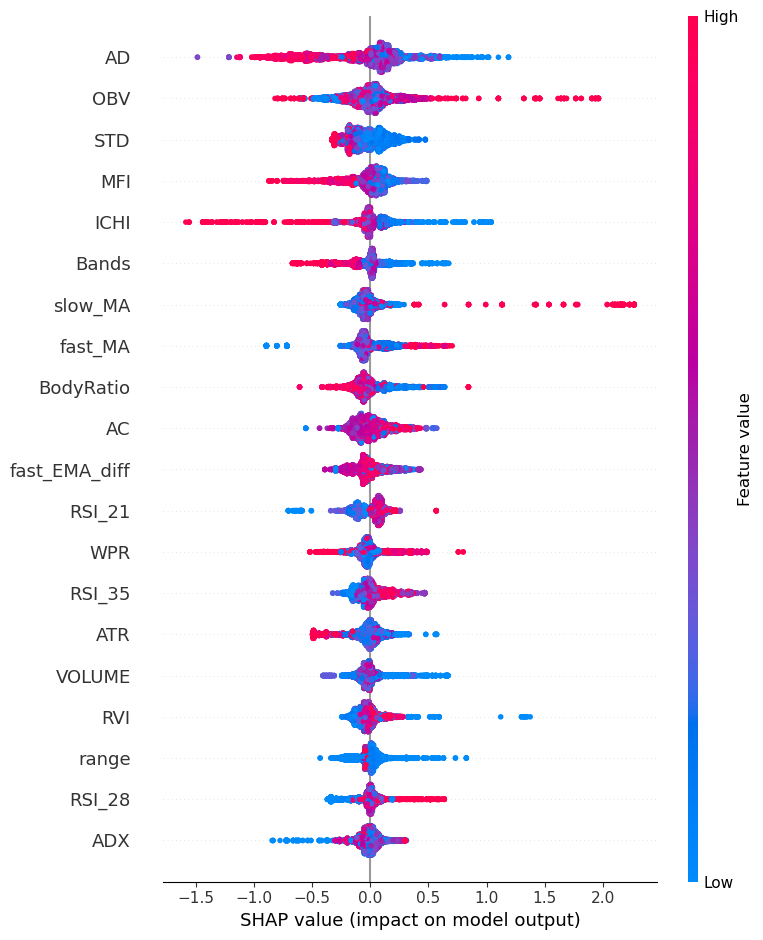


Top Feature: RSI_28


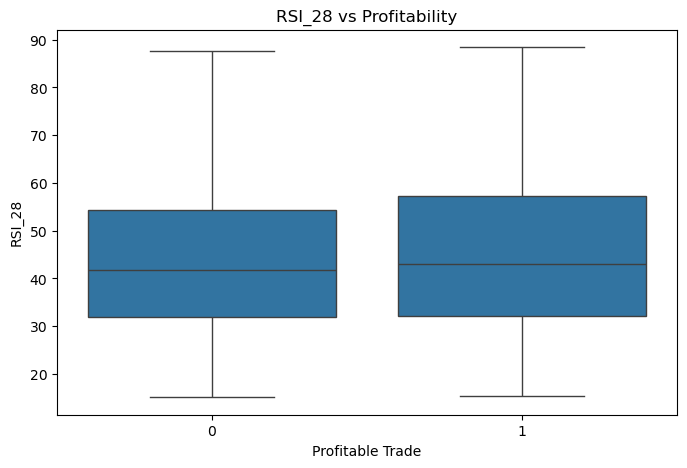

In [22]:
exclude_cols = [
    "Profit",
    "Target",
    'Test_ID',
    'Type_open',
    'Ticket'
]

X = long_train_df.drop(columns=exclude_cols)
y = long_train_df["Target"]

# =========================================================
# 4. HANDLE NON-NUMERIC COLUMNS
# =========================================================

# Convert categorical columns automatically
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(0)

# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 6. DECISION TREE
# =========================================================
tree_model = DecisionTreeClassifier(
    max_depth=1,
    min_samples_leaf=50,
    min_samples_split=100,
    ccp_alpha=0.001
)

tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, tree_preds))
print(classification_report(y_test, tree_preds))

# =========================================================
# 7. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

# =========================================================
# 8. XGBOOST
# =========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

# =========================================================
# 9. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n=== Top Indicators ===")
print(importance_df.head(20))

# Plot top features
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Indicator Importances (XGBoost)")
plt.tight_layout()
plt.show()

# =========================================================
# 10. SHAP ANALYSIS
# =========================================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# Detailed SHAP plot
shap.summary_plot(
    shap_values,
    X_test
)

# =========================================================
# 11. OPTIONAL:
# SHOW WHICH FEATURES INCREASE WIN RATE
# =========================================================

top_feature = importance_df.iloc[0]["feature"]

print(f"\nTop Feature: {top_feature}")

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=y,
    y=X[top_feature]
)

plt.title(f"{top_feature} vs Profitability")
plt.xlabel("Profitable Trade")
plt.show()

In [23]:
from sklearn.tree import export_text

rules = export_text(
    tree_model,
    feature_names=list(X.columns),
    decimals=10
)

print(rules)

|--- slow_MA <= 1.2318817973
|   |--- class: 0
|--- slow_MA >  1.2318817973
|   |--- class: 1

